# Plot Fusion Reconstruction Losses

This notebook loads `history.csv` from a fusion reconstruction run and plots the reconstruction-loss curves.

The main curves are:
- training reconstruction loss
- validation fused reconstruction loss
- validation VAE-only reconstruction loss

In [1]:
from __future__ import annotations

import csv
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
RUN_DIR = PROJECT_ROOT / 'fusion_reconstruction_runs' / 'shard0_ep5'
RUN_DIR

PosixPath('/Users/hengwei/Desktop/AGILE-WM/fusion_reconstruction_runs/shard0_ep5')

In [11]:
def load_history(run_dir: Path) -> dict[str, list[float]]:
    history_path = run_dir / 'history.csv'
    if not history_path.exists():
        raise FileNotFoundError(f'Could not find history.csv in {run_dir}')

    columns = {
        'epoch': [],
        'train_recon_loss': [],
        'val_fused_recon_loss': [],
        'val_vae_recon_loss': [],
    }

    with history_path.open('r', encoding='utf-8', newline='') as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            columns['epoch'].append(int(row['epoch']))
            columns['train_recon_loss'].append(float(row['train_recon_loss']))
            columns['val_fused_recon_loss'].append(float(row['val_fused_recon_loss']))
            columns['val_vae_recon_loss'].append(float(row['val_vae_recon_loss']))

    return columns


def plot_history(run_dir: Path) -> dict[str, list[float]]:
    history = load_history(run_dir)
    epochs = history['epoch']

    fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

    ax.plot(epochs, history['train_recon_loss'], marker='o', linewidth=2, label='Train reconstruction')
    ax.plot(epochs, history['val_fused_recon_loss'], marker='o', linewidth=2, label='Val fused reconstruction')
    ax.plot(epochs, history['val_vae_recon_loss'], marker='o', linewidth=2, label='Val VAE-only reconstruction')
    ax.set_title('Reconstruction Loss Curves')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()
    plt.show()

    return history

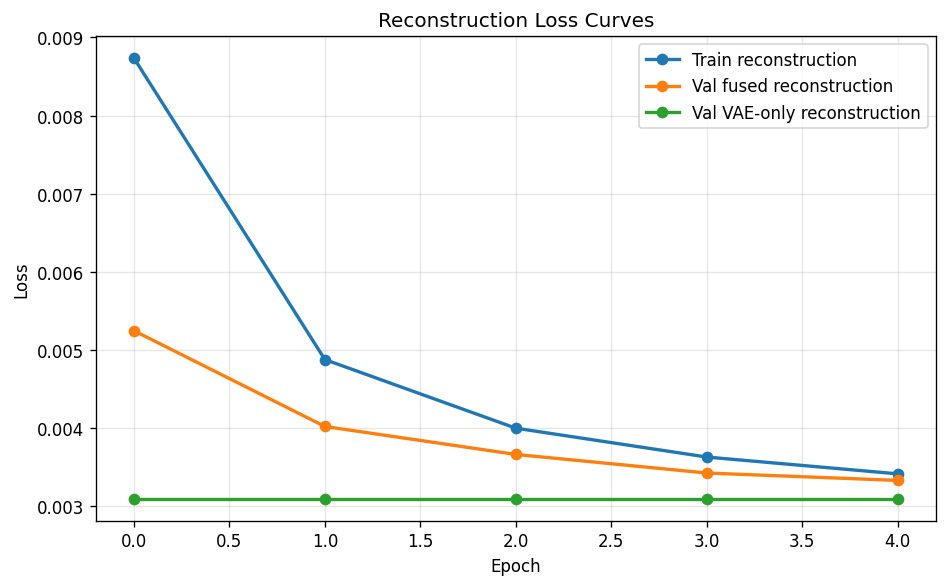

{'epoch': [0, 1, 2, 3, 4],
 'train_recon_loss': [0.008737246441686976,
  0.004879007485277694,
  0.004000901822643033,
  0.0036317611771539368,
  0.0034165660256584144],
 'val_fused_recon_loss': [0.005248414934612811,
  0.004022906068712473,
  0.003665112308226526,
  0.003427255025599152,
  0.0033326217671856284],
 'val_vae_recon_loss': [0.0030995304114185274,
  0.0030995304114185274,
  0.0030995304114185274,
  0.0030995304114185274,
  0.0030995304114185274]}

In [12]:
history = plot_history(RUN_DIR)
history

In [4]:
def list_available_runs(root: Path) -> list[Path]:
    return sorted(path for path in root.iterdir() if path.is_dir() and (path / 'history.csv').exists())


available_runs = list_available_runs(PROJECT_ROOT / 'fusion_reconstruction_runs')
[run.name for run in available_runs]

['path_check_smoke', 'preview_label_smoke', 'shard0_ep5']

In [5]:
def compare_validation_curves(run_dirs: list[Path]) -> None:
    plt.figure(figsize=(10, 5), dpi=120)
    for run_dir in run_dirs:
        history = load_history(run_dir)
        plt.plot(
            history['epoch'],
            history['val_fused_recon_loss'],
            marker='o',
            linewidth=2,
            label=f'{run_dir.name} (fused)'
        )
    plt.title('Validation Fused Reconstruction Loss Across Runs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

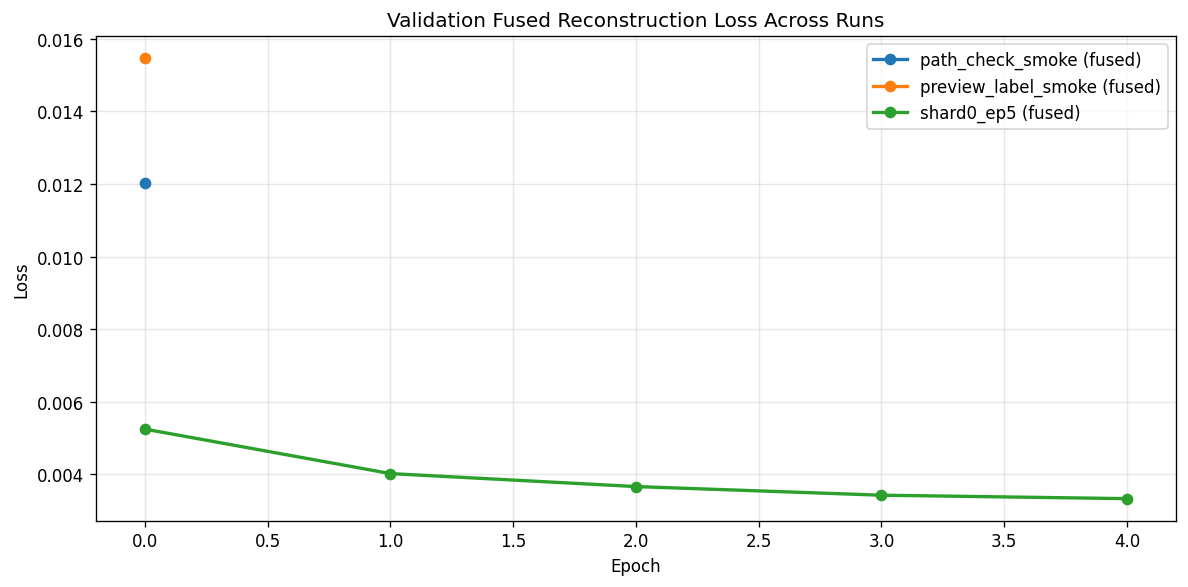

In [6]:
compare_validation_curves(available_runs)